# Empirical operator-norm resource comparison

This notebook compares opt-in, non-certified empirical sizing with the existing analytical estimators. Empirical MPF values concern the repeated ideal MPF operator; aggregate-only schedule costs do not imply an implementable circuit. All plots therefore use `certification_policy="unconstrained"`.

In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from hamiltonian_resources import (
    BenchmarkConfig, HamiltonianSpec, MultiproductMethod, QSVTMethod,
    TimeScaling, TrotterMethod, plot_benchmark, run_benchmark,
    select_best_by_family,
)

MODEL = os.environ.get("HAMILTONIAN_EMPIRICAL_MODEL", "tfim")
REDUCED_GRID = os.environ.get("HAMILTONIAN_NOTEBOOK_REDUCED") == "1"
if MODEL == "tfim":
    model = HamiltonianSpec("transverse_field_ising", {"coupling": 1.0, "field": 3.0, "periodic": False})
elif MODEL == "heisenberg":
    model = HamiltonianSpec("heisenberg_chain", {"coupling": 1.0, "field_z": 0.3})
else:
    raise ValueError("MODEL must be 'tfim' or 'heisenberg'")

/Users/xisn/Documents/001_hamiltonian_simulation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
system_sizes = np.rint(np.geomspace(5, 100, num=20)).astype(np.int_)
target_errors = np.logspace(-1, -9, 11)
if REDUCED_GRID:
    system_sizes = [4]
    target_errors = [1e-2]

methods = [
    *(TrotterMethod(p, "empirical-operator-norm") for p in (2, 4, 6)),
    MultiproductMethod(None, error_method="empirical-operator-norm", branch_count_policy="mizuta2026-theorem6"),
    QSVTMethod(),
    *(TrotterMethod(p) for p in (2, 4, 6)),
    MultiproductMethod(None, error_method="mizuta2026-commutator-ideal-rigorous", branch_count_policy="mizuta2026-theorem6"),
]
config = BenchmarkConfig(
    hamiltonian=model, system_sizes=system_sizes, target_errors=target_errors,
    time=TimeScaling("proportional", 1.0), fixed_system_size=8,
    fixed_target_error=1e-3, methods=methods,
)
data = run_benchmark(config)
data.groupby(["sweep", "status"]).size()

sweep         status
system-size   error       6
              ok        174
target-error  error       6
              ok         93
dtype: int64

In [3]:
def best_trotter(frame, metric, sweep, policy):
    candidates = frame[(frame.method_family == "trotter") & (frame.error_policy == policy)]
    return select_best_by_family(candidates, metric, sweep=sweep, certification_policy="unconstrained")

def comparison_rows(frame, metric, sweep, comparison):
    empirical_trotter = best_trotter(frame, metric, sweep, "empirical-operator-norm").copy()
    empirical_trotter["summary_label"] = "Best empirical Trotter [non-certified]"
    empirical_mpf = frame[(frame.sweep == sweep) & (frame.method_family == "multiproduct") & (frame.error_policy == "empirical-operator-norm")].copy()
    empirical_mpf["summary_label"] = "Empirical ideal MPF [non-certified]"
    if comparison == "families":
        qsvt = frame[(frame.sweep == sweep) & (frame.method_family == "qsvt")].copy()
        qsvt["summary_label"] = "QSVT (ideal scope)"
        return pd.concat([empirical_trotter, empirical_mpf, qsvt], ignore_index=True)
    if comparison == "trotter":
        analytical = best_trotter(frame, metric, sweep, "analytical").copy()
        analytical["summary_label"] = "Best analytical Trotter"
        return pd.concat([analytical, empirical_trotter], ignore_index=True)
    refined = frame[(frame.sweep == sweep) & (frame.error_policy == "mizuta2026-commutator-ideal-rigorous")].copy()
    refined["summary_label"] = "Mizuta refined ideal MPF"
    return pd.concat([refined, empirical_mpf], ignore_index=True)

def draw_comparisons(frame, sweep):
    for metric in ("cnot_count", "t_count"):
        for comparison in ("families", "trotter", "mpf"):
            rows = comparison_rows(frame, metric, sweep, comparison)
            plot_benchmark(rows, sweep=sweep, metric=metric, series_by="summary_label", certification_policy="unconstrained")
            plt.show()

/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:489: FutureWarning: Downcasting obj

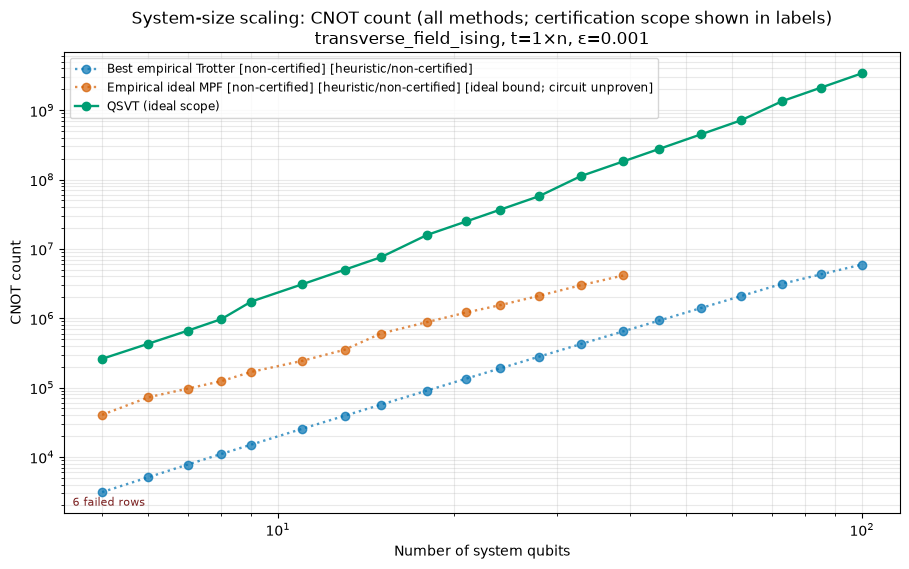

/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)


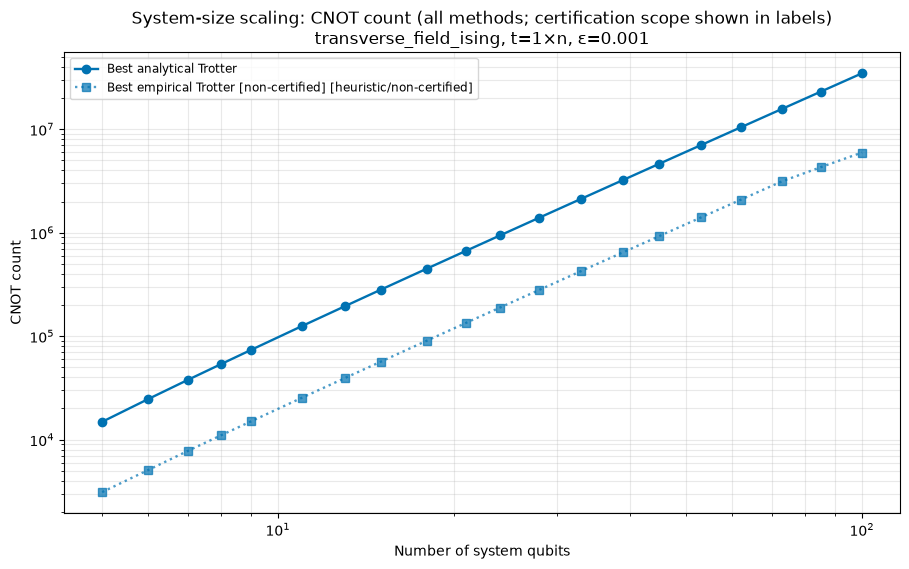

/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:489: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  values["circuit_bound_rigorous"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dt

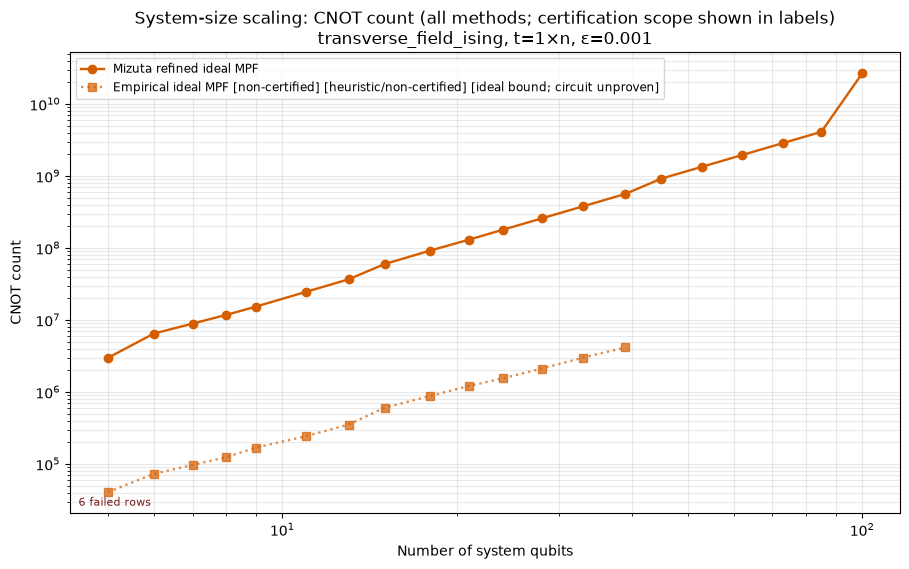

/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:489: FutureWarning: Downcasting obj

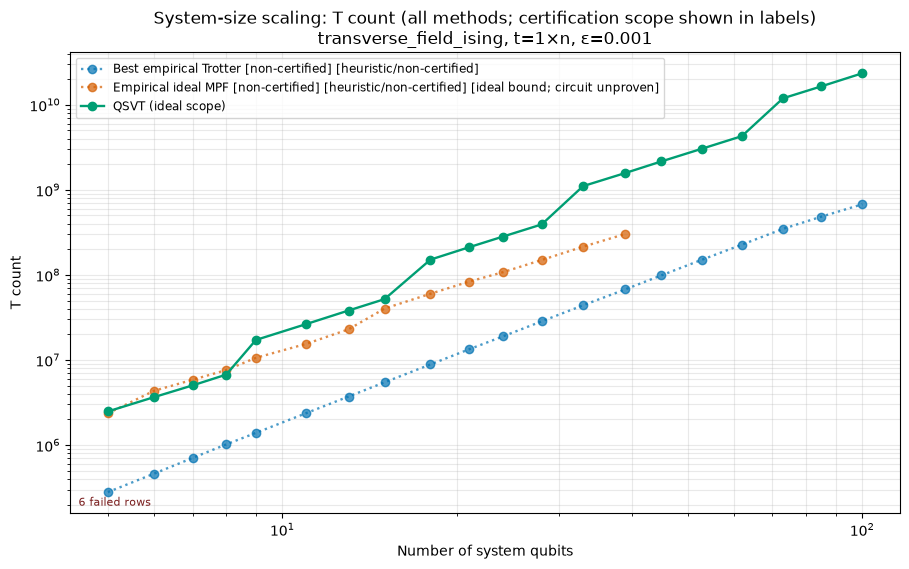

/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)


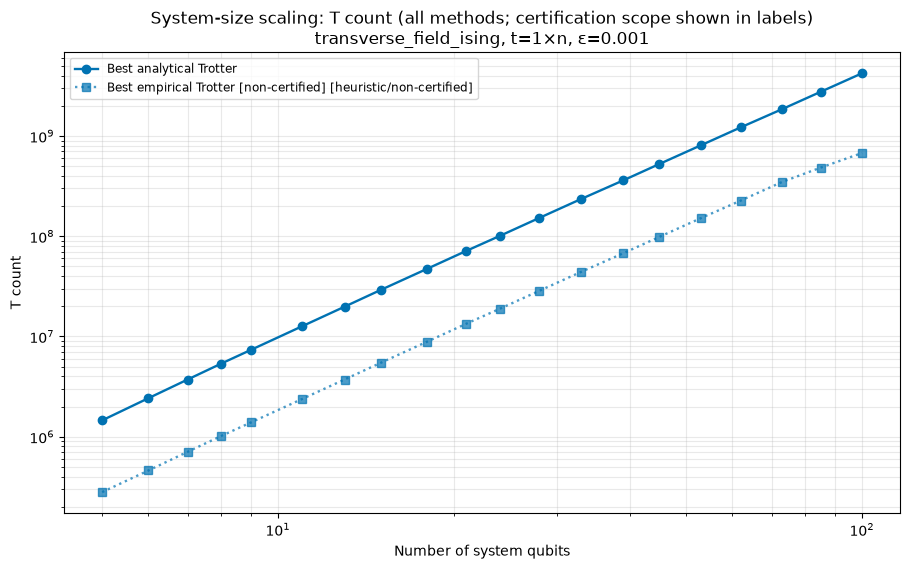

/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:489: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  values["circuit_bound_rigorous"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dt

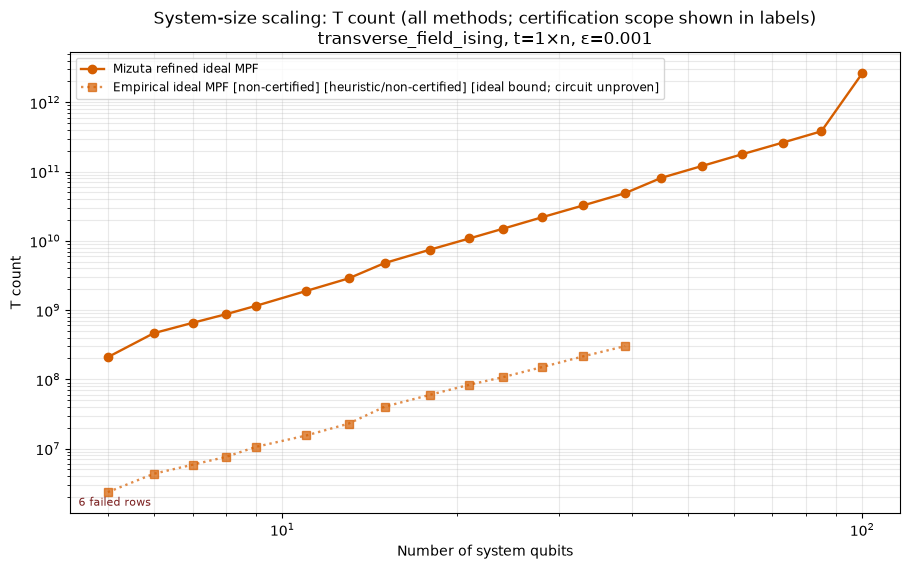

/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:489: FutureWarning: Downcasting obj

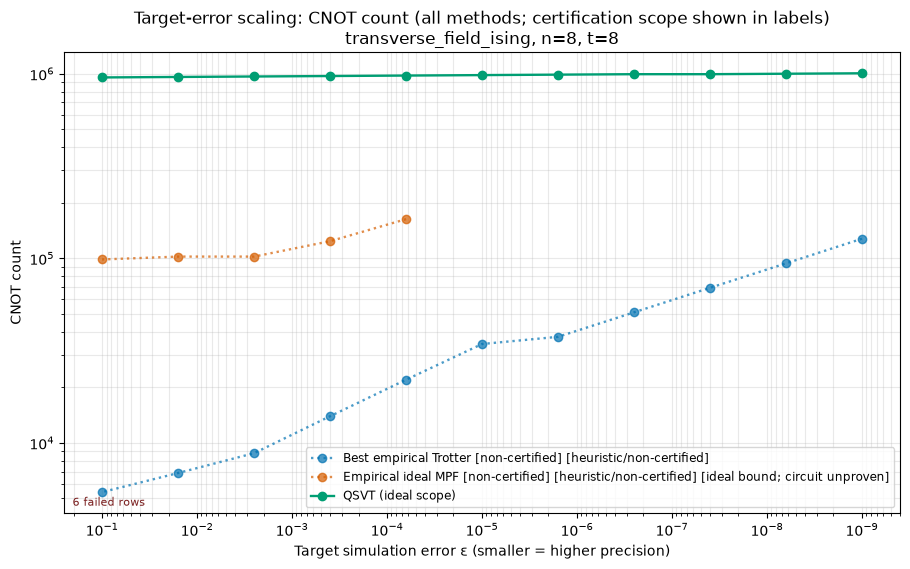

/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)


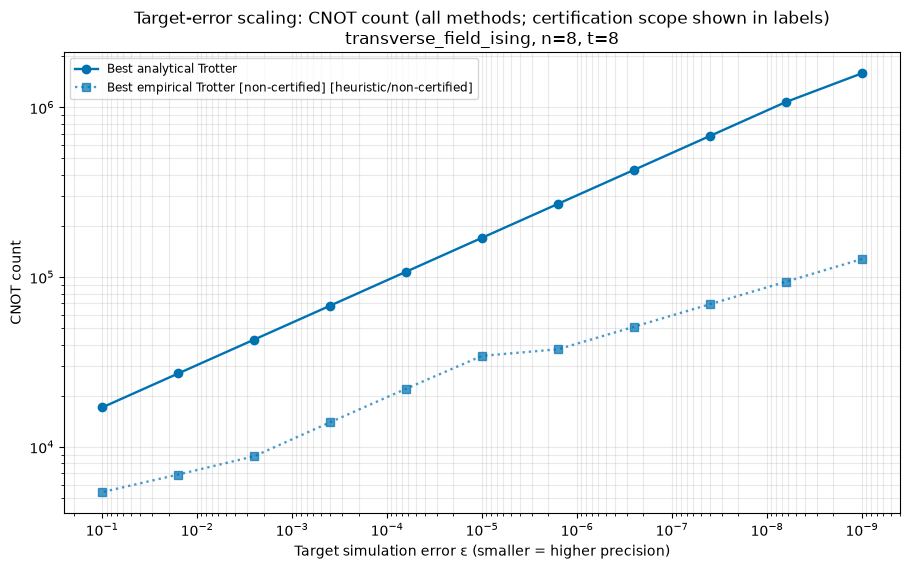

/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:489: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  values["circuit_bound_rigorous"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dt

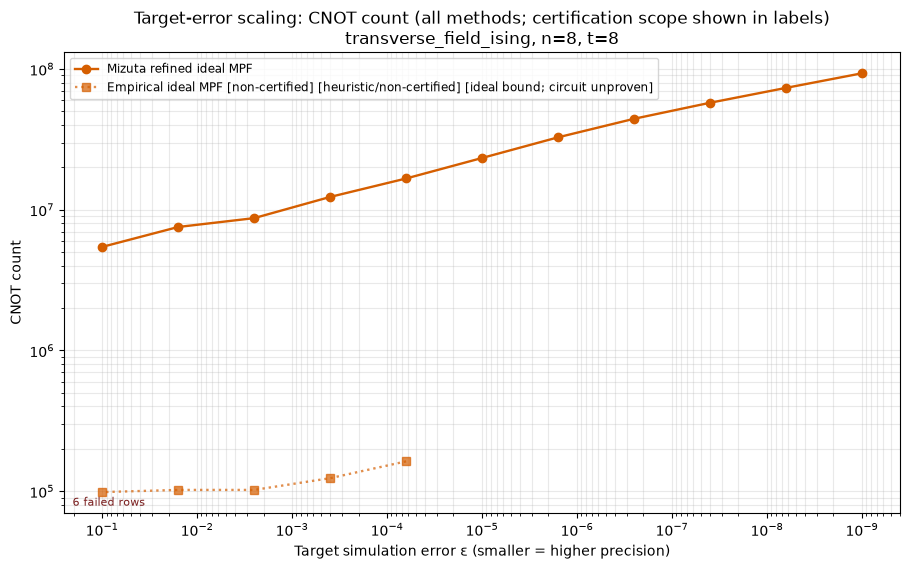

/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:489: FutureWarning: Downcasting obj

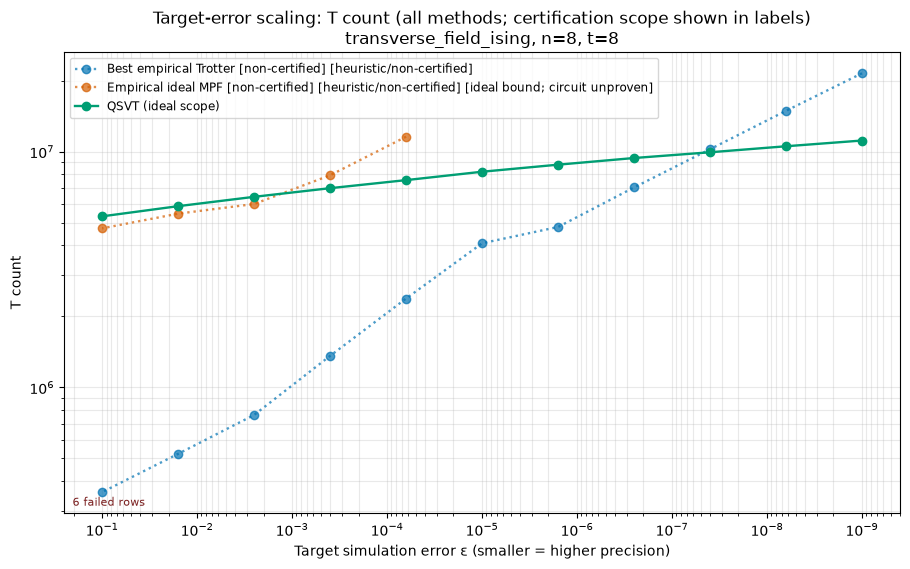

/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)


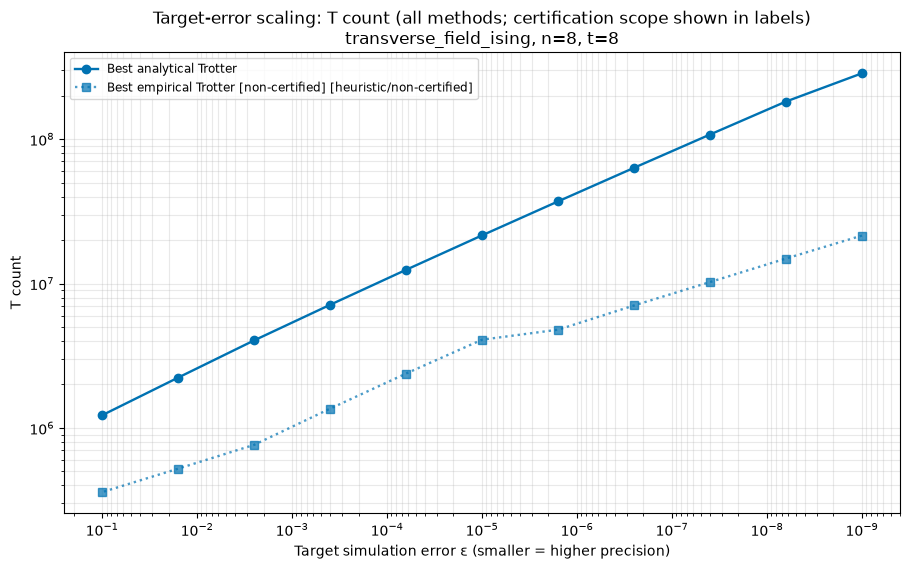

/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return frame["bound_target_satisfied"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:489: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  values["circuit_bound_rigorous"].fillna(False).astype(bool)
/Users/xisn/Documents/001_hamiltonian_simulation/src/hamiltonian_resources/benchmark_plotting.py:283: FutureWarning: Downcasting object dt

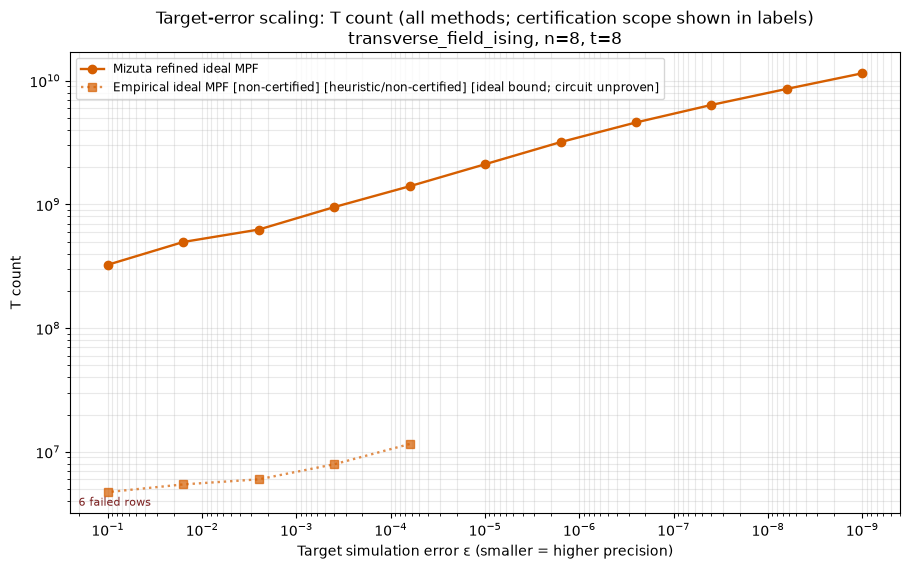

In [8]:
draw_comparisons(data, "system-size")
draw_comparisons(data, "target-error")

In [9]:
diagnostic_columns = [
    "sweep", "system_qubits", "target_error", "method_label",
    "trotter_order", "mpf_term_count", "segment_count",
    "empirical_calibration_id", "empirical_size_extrapolated",
    "empirical_time_extrapolated", "empirical_active_constraint",
    "mpf_exponent_sum", "mpf_exponent_sum_source",
    "mpf_explicit_schedule_available", "status", "error_message",
]
diagnostics = []
for sweep in ("system-size", "target-error"):
    for metric in ("cnot_count", "t_count"):
        selected = best_trotter(data, metric, sweep, "empirical-operator-norm").copy()
        selected["selection_metric"] = metric
        diagnostics.append(selected)
selected_trotter_diagnostics = pd.concat(diagnostics, ignore_index=True)
selected_trotter_diagnostics[["selection_metric", *diagnostic_columns[:-2]]]

,selection_metric,sweep,system_qubits,target_error,method_label,trotter_order,mpf_term_count,segment_count,empirical_calibration_id,empirical_size_extrapolated,empirical_time_extrapolated,empirical_active_constraint,mpf_exponent_sum,mpf_exponent_sum_source,mpf_explicit_schedule_available
0,cnot_count,system-size,5,0.001000,Trotter p=4 [empirical],4.0,NaN,50.0,opnorm-v1-tfim-open-trotter-p4,False,False,formula,NaN,None,None
1,cnot_count,system-size,6,0.001000,Trotter p=4 [empirical],4.0,NaN,66.0,opnorm-v1-tfim-open-trotter-p4,False,False,formula,NaN,None,None
2,cnot_count,system-size,7,0.001000,Trotter p=4 [empirical],4.0,NaN,84.0,opnorm-v1-tfim-open-trotter-p4,False,False,formula,NaN,None,None
3,cnot_count,system-size,8,0.001000,Trotter p=4 [empirical],4.0,NaN,103.0,opnorm-v1-tfim-open-trotter-p4,False,False,formula,NaN,None,None
4,cnot_count,system-size,9,0.001000,Trotter p=4 [empirical],4.0,NaN,123.0,opnorm-v1-tfim-open-trotter-p4,False,False,formula,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,t_count,target-error,8,0.000063,Trotter p=4 [empirical],4.0,NaN,205.0,opnorm-v1-tfim-open-trotter-p4,False,False,formula,NaN,None,None
58,t_count,target-error,8,0.000398,Trotter p=4 [empirical],4.0,NaN,130.0,opnorm-v1-tfim-open-trotter-p4,False,False,formula,NaN,None,None
59,t_count,target-error,8,0.002512,Trotter p=4 [empirical],4.0,NaN,82.0,opnorm-v1-tfim-open-trotter-p4,False,False,formula,NaN,None,None
60,t_count,target-error,8,0.015849,Trotter p=4 [empirical],4.0,NaN,64.0,opnorm-v1-tfim-open-trotter-p4,False,False,asymptotic-domain,NaN,None,None


In [6]:
data[data.error_policy == "empirical-operator-norm"][diagnostic_columns]

,sweep,system_qubits,target_error,method_label,trotter_order,mpf_term_count,segment_count,empirical_calibration_id,empirical_size_extrapolated,empirical_time_extrapolated,empirical_active_constraint,mpf_exponent_sum,mpf_exponent_sum_source,mpf_explicit_schedule_available,status,error_message
0,system-size,4,0.001000,Trotter p=2 [empirical],2.0,NaN,470.0,opnorm-v1-tfim-open-trotter-p2,False,False,formula,NaN,None,None,ok,None
1,system-size,4,0.001000,Trotter p=4 [empirical],4.0,NaN,36.0,opnorm-v1-tfim-open-trotter-p4,False,False,formula,NaN,None,None,ok,None
2,system-size,4,0.001000,Trotter p=6 [empirical],6.0,NaN,32.0,opnorm-v1-tfim-open-trotter-p6,False,False,asymptotic-domain,NaN,None,None,ok,None
3,system-size,4,0.001000,MPF J=Mizuta Theorem 6 (resolved per point) [e...,NaN,6.0,6.0,opnorm-v1-tfim-open-mpf-new-m6,False,False,asymptotic-domain,32.0,registered-exact,True,ok,None
9,system-size,6,0.001000,Trotter p=2 [empirical],2.0,NaN,1100.0,opnorm-v1-tfim-open-trotter-p2,False,False,formula,NaN,None,None,ok,None
10,system-size,6,0.001000,Trotter p=4 [empirical],4.0,NaN,66.0,opnorm-v1-tfim-open-trotter-p4,False,False,formula,NaN,None,None,ok,None
11,system-size,6,0.001000,Trotter p=6 [empirical],6.0,NaN,48.0,opnorm-v1-tfim-open-trotter-p6,False,False,asymptotic-domain,NaN,None,None,ok,None
12,system-size,6,0.001000,MPF J=Mizuta Theorem 6 (resolved per point) [e...,NaN,7.0,8.0,opnorm-v1-tfim-open-mpf-new-m7,False,False,asymptotic-domain,46.0,registered-exact,True,ok,None
18,system-size,8,0.001000,Trotter p=2 [empirical],2.0,NaN,1991.0,opnorm-v1-tfim-open-trotter-p2,False,False,formula,NaN,None,None,ok,None
19,system-size,8,0.001000,Trotter p=4 [empirical],4.0,NaN,103.0,opnorm-v1-tfim-open-trotter-p4,False,False,formula,NaN,None,None,ok,None
